# Rapido Ride Demand & Product Optimization Analysis
#### Problem Statement:
How can Rapido optimize demand, pricing, and user experience to maximize revenue and reduce inefficiencies?

### Data Source

The dataset used for this analysis was sourced from Kaggle:
[Bangalore Rapido Ride Services Dataset](https://www.kaggle.com/datasets/vishaldeoprasad/bangalore-rapido-ride-services-dataset)

The dataset contains ride-level information including service type, ride status, fare, time, location, and payment details, enabling analysis of user behavior and operational patterns.

### Analysis Overview
This project focuses on understanding ride demand patterns and service-level performance to identify opportunities for optimization.

#### 1. Demand Analysis
- Analyzed ride distribution across hours using time-based features
- Identified peak and off-peak hours
- Visualized demand patterns using bar charts and heatmaps

#### 2. Service Type Analysis
Compared ride volume across services (bike, auto, cab, etc.)
Evaluated:
- Revenue contribution
- Cancellation rates
- Pricing efficiency (fare per km)
Identified differences in performance and reliability across services

##### Derived insights from the analysis to propose data-driven product optimization strategies focused on improving demand utilization, service reliability, and overall user experience.

In [1]:
import sys
!{sys.executable} -m pip install kagglehub


[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import kagglehub
import pandas as pd
import os

In [3]:
# Downloading the dataset
path = kagglehub.dataset_download("vishaldeoprasad/bangalore-rapido-ride-services-dataset")

print("Path to dataset files:", path)

Path to dataset files: C:\Users\user\.cache\kagglehub\datasets\vishaldeoprasad\bangalore-rapido-ride-services-dataset\versions\1


In [4]:
print(os.listdir(path))

['rides_data.csv']


In [5]:
df=pd.read_csv(path+'/rides_data.csv')

In [6]:
df.head()

,services,date,time,ride_status,source,destination,duration,ride_id,distance,ride_charge,misc_charge,total_fare,payment_method
0,cab economy,2024-07-15,08:30:40.542646,completed,Balagere Harbor,Harohalli Nagar,39,RD3161218751875354,27.21,764.83,31.51,796.34,Amazon Pay
1,auto,2024-07-05,23:36:51.542646,completed,Basavanagudi 3rd Block,Bikasipura 1st Stage,89,RD8171514284594096,34.03,314.83,49.52,364.35,Paytm
2,auto,2024-07-23,11:05:37.542646,cancelled,Babusapalya Cove,Kothaguda Terrace,25,RD9376481122237926,20.24,NaN,NaN,NaN,NaN
3,cab economy,2024-06-24,08:45:10.542646,completed,Mahadevapura Mews,Kanakapura Arc,89,RD3676889143182765,31.17,484.73,15.84,500.57,QR scan
4,cab economy,2024-07-15,00:26:44.542646,completed,Ganganagar Cove,Basaveshwaranagar Colony,95,RD6639410275948084,27.21,663.50,14.13,677.63,Amazon Pay


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   services        50000 non-null  object 
 1   date            50000 non-null  object 
 2   time            50000 non-null  object 
 3   ride_status     50000 non-null  object 
 4   source          50000 non-null  object 
 5   destination     50000 non-null  object 
 6   duration        50000 non-null  int64  
 7   ride_id         50000 non-null  object 
 8   distance        50000 non-null  float64
 9   ride_charge     44964 non-null  float64
 10  misc_charge     44964 non-null  float64
 11  total_fare      44964 non-null  float64
 12  payment_method  44964 non-null  object 
dtypes: float64(4), int64(1), object(8)
memory usage: 5.0+ MB


In [8]:
df.describe()


,duration,distance,ride_charge,misc_charge,total_fare
count,50000.000000,50000.000000,44964.000000,44964.000000,44964.000000
mean,64.320100,25.528243,522.428805,24.964289,547.393093
std,31.852336,14.177136,274.726031,14.459417,275.094813
min,10.000000,1.000000,50.030000,0.000000,50.580000
25%,37.000000,13.260000,283.657500,12.400000,308.920000
50%,64.000000,25.460000,520.030000,25.070000,544.920000
75%,92.000000,37.860000,759.367500,37.510000,785.502500
max,119.000000,50.000000,999.960000,50.000000,1048.800000


In [9]:
df.isnull().sum()

services             0
date                 0
time                 0
ride_status          0
source               0
destination          0
duration             0
ride_id              0
distance             0
ride_charge       5036
misc_charge       5036
total_fare        5036
payment_method    5036
dtype: int64

In [10]:
#checking if all the cancelled rides are the null values
df['ride_status'].value_counts()

ride_status
completed    44964
cancelled     5036
Name: count, dtype: int64

## 1. Demand Analysis
When is demand highest?


In [11]:
#convertingdate
df['time'] = pd.to_datetime(df['time'], format='%H:%M:%S.%f', errors='coerce')
df['hour'] = df['time'].dt.hour


In [12]:
df.head()

,services,date,time,ride_status,source,destination,duration,ride_id,distance,ride_charge,misc_charge,total_fare,payment_method,hour
0,cab economy,2024-07-15,1900-01-01 08:30:40.542646,completed,Balagere Harbor,Harohalli Nagar,39,RD3161218751875354,27.21,764.83,31.51,796.34,Amazon Pay,8
1,auto,2024-07-05,1900-01-01 23:36:51.542646,completed,Basavanagudi 3rd Block,Bikasipura 1st Stage,89,RD8171514284594096,34.03,314.83,49.52,364.35,Paytm,23
2,auto,2024-07-23,1900-01-01 11:05:37.542646,cancelled,Babusapalya Cove,Kothaguda Terrace,25,RD9376481122237926,20.24,NaN,NaN,NaN,NaN,11
3,cab economy,2024-06-24,1900-01-01 08:45:10.542646,completed,Mahadevapura Mews,Kanakapura Arc,89,RD3676889143182765,31.17,484.73,15.84,500.57,QR scan,8
4,cab economy,2024-07-15,1900-01-01 00:26:44.542646,completed,Ganganagar Cove,Basaveshwaranagar Colony,95,RD6639410275948084,27.21,663.50,14.13,677.63,Amazon Pay,0


Instead of assuming peak hours, I analyzed ride distribution across time and identified peak periods based on actual demand patterns.

In [13]:
rides_per_hour = df['hour'].value_counts().sort_index()
rides_per_hour

hour
0     2037
1     2105
2     2000
3     2066
4     2082
5     2103
6     2073
7     2112
8     2106
9     2185
10    2114
11    2181
12    2070
13    2111
14    2017
15    2082
16    2026
17    2095
18    2094
19    2086
20    2073
21    2083
22    2096
23    2003
Name: count, dtype: int64

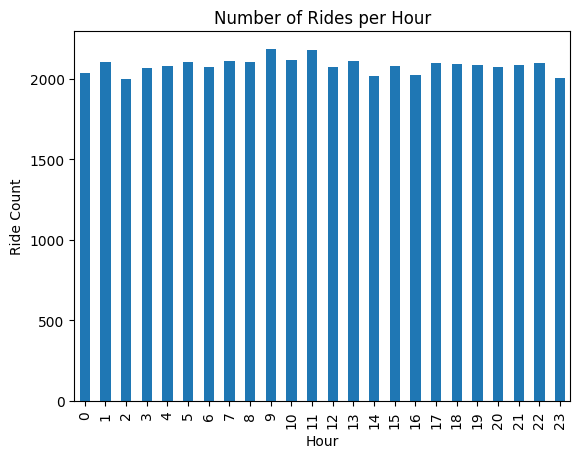

In [14]:
import matplotlib.pyplot as plt

plt.figure()
rides_per_hour.plot(kind='bar')
plt.title("Number of Rides per Hour")
plt.xlabel("Hour")
plt.ylabel("Ride Count")
plt.show()

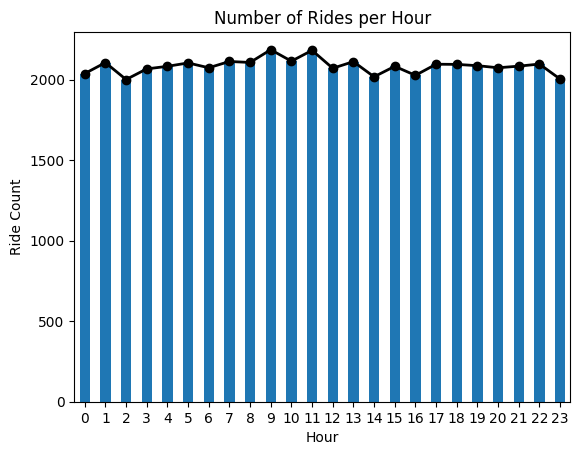

In [15]:
plt.figure()

ax = rides_per_hour.plot(kind='bar')

# Overlay line
rides_per_hour.plot(ax=ax, marker='o',color='black',linewidth=2)

plt.title("Number of Rides per Hour")
plt.xlabel("Hour")
plt.ylabel("Ride Count")

plt.show()

In [16]:
peak_specific_hours = rides_per_hour.sort_values(ascending=False).head(5).index
peak_specific_hours

Index([9, 11, 10, 7, 13], dtype='int32', name='hour')

In [17]:
def peak_hour(hour):
    if (7 <= hour <= 11) or (hour == 13) or (17 <= hour <= 22):
        return "Peak"
    else:
        return "Off-Peak"

df['peak_type'] = df['hour'].apply(peak_hour)

In [18]:
df['peak_type'].value_counts()

peak_type
Peak        25336
Off-Peak    24664
Name: count, dtype: int64

Peak hours were defined based on observed demand patterns, including morning (7–11 AM), evening (5–10 PM), and an additional spike at 1 PM, indicating potential mid-day demand.
Approximately 51% of rides occur during identified peak periods, indicating a relatively balanced demand distribution with slightly higher activity during peak hours.

In [19]:
df.head()

,services,date,time,ride_status,source,destination,duration,ride_id,distance,ride_charge,misc_charge,total_fare,payment_method,hour,peak_type
0,cab economy,2024-07-15,1900-01-01 08:30:40.542646,completed,Balagere Harbor,Harohalli Nagar,39,RD3161218751875354,27.21,764.83,31.51,796.34,Amazon Pay,8,Peak
1,auto,2024-07-05,1900-01-01 23:36:51.542646,completed,Basavanagudi 3rd Block,Bikasipura 1st Stage,89,RD8171514284594096,34.03,314.83,49.52,364.35,Paytm,23,Off-Peak
2,auto,2024-07-23,1900-01-01 11:05:37.542646,cancelled,Babusapalya Cove,Kothaguda Terrace,25,RD9376481122237926,20.24,NaN,NaN,NaN,NaN,11,Peak
3,cab economy,2024-06-24,1900-01-01 08:45:10.542646,completed,Mahadevapura Mews,Kanakapura Arc,89,RD3676889143182765,31.17,484.73,15.84,500.57,QR scan,8,Peak
4,cab economy,2024-07-15,1900-01-01 00:26:44.542646,completed,Ganganagar Cove,Basaveshwaranagar Colony,95,RD6639410275948084,27.21,663.50,14.13,677.63,Amazon Pay,0,Off-Peak


In [20]:
#Do peak hours generate more money?
df.groupby('peak_type')['total_fare'].sum()

peak_type
Off-Peak    12103750.65
Peak        12509232.40
Name: total_fare, dtype: float64

While peak hours show slightly higher revenue (~3%), a significant portion of revenue is still generated during off-peak hours, indicating consistent demand throughout the day

In [21]:
#Average fare during peak and off-peak hours
df.groupby('peak_type')['total_fare'].mean()

peak_type
Off-Peak    546.444725
Peak        548.313860
Name: total_fare, dtype: float64

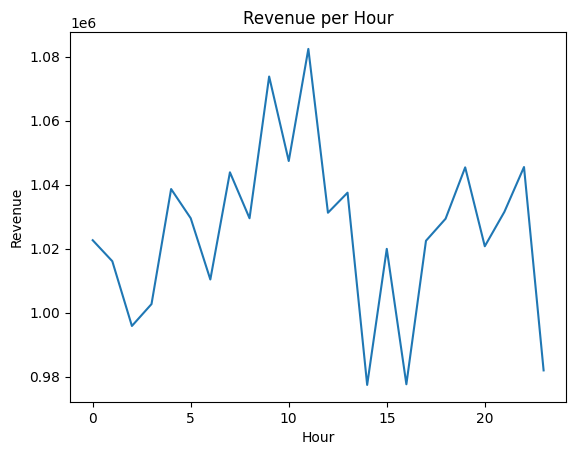

In [22]:
revenue_per_hour = df.groupby('hour')['total_fare'].sum()

plt.figure()
revenue_per_hour.plot(kind='line')
plt.title("Revenue per Hour")
plt.xlabel("Hour")
plt.ylabel("Revenue")
plt.show()

Revenue distribution between peak and off-peak hours is relatively balanced, with peak contributing slightly more (~3%). This suggests that while peak optimization is important, off-peak periods represent a significant opportunity for demand stimulation strategies.

## Product Optimization 

### 1.Dynamic Pricing
Minimal variation in average fare between peak and off-peak hours suggests an opportunity to implement dynamic pricing to better capture peak demand.

- Peak demand exists but pricing isn’t reacting to it
- Introduce mild surge pricing (5–10%) during peak hours
- Increase fares gradually instead of aggressive spikes

Expected impact:
- Higher revenue per ride
- Better supply-demand balance

### 2. Improve Off-Peak Demand
Given comparable cancellation rates and significant revenue contribution, off-peak periods can be targeted with incentives to boost demand.

- Off-peak contributes ~50% of revenue
- Huge opportunity to grow usage

What Rapido could do :
- Push notifications to remind the user of tasks or schedules they otherwise might forget
- Offer discounts during low-demand hours

Expected impact:
- Increase ride volume during idle periods
- Better driver utilization

### 3. Introduce Time-Based Campaigns
The presence of a distinct mid-day spike (hour 13) shows potential for targeted time-based campaigns.

1:00 PM demand spike = repeatable behavior, most likely short trips (lunch, errands)

What Rapido could do:
- Launch “Lunch Hour Rides” offers
- Partner up with restaurants

Expected impact:
- Capture predictable mid-day demand
- Increase frequency of short trips

## 2.Service Type Analysis (bike vs auto vs cab)

In [23]:
df.columns

Index(['services', 'date', 'time', 'ride_status', 'source', 'destination',
       'duration', 'ride_id', 'distance', 'ride_charge', 'misc_charge',
       'total_fare', 'payment_method', 'hour', 'peak_type'],
      dtype='object')

In [24]:
service_counts = df['services'].value_counts()
service_counts

services
bike           15128
auto           12327
cab economy    10202
parcel          7459
bike lite       4884
Name: count, dtype: int64

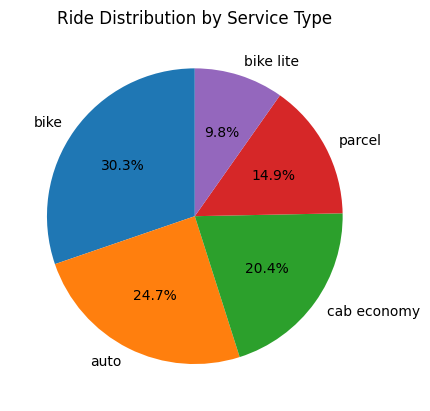

In [25]:
import matplotlib.pyplot as plt

plt.figure()
service_counts.plot(
    kind='pie',
    autopct='%1.1f%%',   
    startangle=90       
)

plt.title("Ride Distribution by Service Type")
plt.ylabel('') 
plt.show()

In [26]:
revenue_by_service = df.groupby('services')['total_fare'].sum().sort_values(ascending=False)
revenue_by_service

services
bike           7432783.95
auto           6099731.32
cab economy    5006233.04
parcel         3686514.15
bike lite      2387720.59
Name: total_fare, dtype: float64

In [27]:
cancel_rate_service = df.groupby('services')['ride_status'].apply(
    lambda x: (x == 'cancelled').mean()
).sort_values(ascending=False)

cancel_rate_service

services
cab economy    0.103313
bike           0.103186
bike lite      0.101556
auto           0.098402
parcel         0.095455
Name: ride_status, dtype: float64

In [28]:
df[df['ride_status'] == 'cancelled']['services'].value_counts()

services
bike           1561
auto           1213
cab economy    1054
parcel          712
bike lite       496
Name: count, dtype: int64

## Analysis
### 1. Bike Lite is the Least Used Service
Bike Lite has the lowest ride volume, indicating weak user adoption compared to other service types. Not very surprising as it is a recently introduced service

What this could mean:
- Poor visibility in app
- Not clearly differentiated from “Bike”
- Limited availability of drivers
- Not much difference in fare from normal bike

### 2. Cab Shows Slightly Higher Cancellations
- Cab services exhibit marginally higher cancellation rates, possibly due to longer wait times, higher fares, or supply constraints.
- Cancellation rates are largely consistent across services, suggesting platform-level inefficiencies rather than service-specific problems

## Product Optimization 

### 1. Fix Bike Lite Adoption

Low usage of Bike Lite suggests a need for repositioning or better visibility.

Actions:
- Highlight it in UI (e.g., “Cheapest ride”,"Sustainable ride" tags)
- Increase driver availability

### 2. Improve Cab Reliability

Slightly higher cancellations in cab services indicate possible friction in availability or pricing.

Actions:
- Increase driver supply during peak hours
- Introduce driver incentives for accepting rides

### 3. Focus on Platform-Level Improvements 

Uniform cancellation rates across services indicate systemic inefficiencies.

Actions:
- Improve matching algorithm
- Reduce wait time visibility mismatch
- Show accurate ETAs
- Optimize driver allocation

### 4. Smart Service Recommendations

Users can be nudged toward more reliable or available services.

Actions:
Suggest tags like,
- “Faster pickup: choose Bike”
- “Lower cancellation risk” for Auto
- "rapido green" for Bike Lite
- "Comfort over cost" for Cabs etc  


### Other Visualizations

In [29]:
heatmap_data = df.pivot_table(
    index='hour',
    values='ride_status',
    aggfunc='count'
)

heatmap_data

,ride_status
hour,
0,2037
1,2105
2,2000
3,2066
4,2082
5,2103
6,2073
7,2112
8,2106


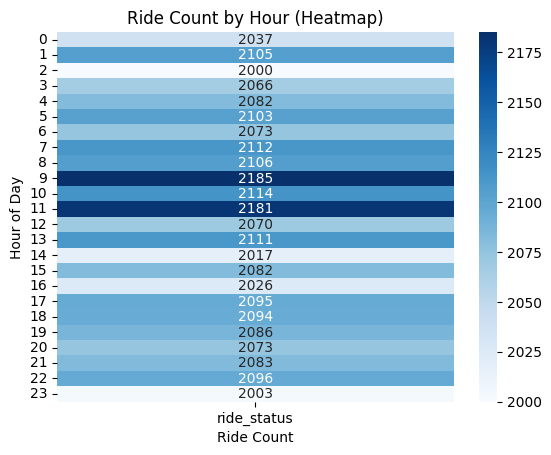

In [30]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure()
sns.heatmap(heatmap_data, annot=True, fmt='d',cmap='Blues')

plt.title("Ride Count by Hour (Heatmap)")
plt.xlabel("Ride Count")
plt.ylabel("Hour of Day")

plt.show()